In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from dotenv import load_dotenv
from typing import TypedDict
import os

load_dotenv()

True

In [2]:
api_key = os.getenv("NVIDIA_API_KEY")

client = ChatNVIDIA(
  model="openai/gpt-oss-120b",
  api_key=api_key, 
  temperature=1,
  top_p=1,
  max_tokens=4096,
)


C:\Users\anish\AppData\Local\Temp\ipykernel_19572\4004952201.py:3: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  client = ChatNVIDIA(


In [ ]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluate: str

In [27]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # cal llm gen outline
    prompt = f"Generate a detailed outline for a blog on the topic - {title}"
    outline = client.invoke(prompt).content

    #update state
    state['outline'] = outline

    return state

In [28]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f"Generate a detailed blog on the topic - {title} with the following outline - \n {outline}"
    content = client.invoke(prompt).content
    state['content'] = content
    return state

In [34]:
def evaluate_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    content = state['content']
    prompt = f"Based on this outline - {outline} rate my blog - {content} on a scale of 1-10"
    evaluate = client.invoke(prompt).content
    state['evaluate'] = evaluate
    return state


In [35]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

#edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)
workflow = graph.compile()

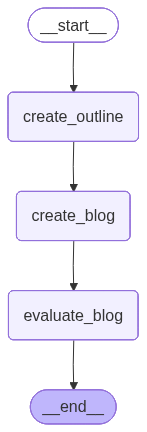

In [36]:
workflow

In [37]:
initial_state = {'title': "The future of AI in healthcare"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'The future of AI in healthcare', 'outline': 'Below is a **ready‑to‑use, detailed outline** for a blog post titled **“The Future of AI in Healthcare”**.  \nFeel free to copy‑paste the headings directly into your CMS (they’re marked with Markdown heading levels) and fill in the bullet‑point prompts with your research, quotes, data, and graphics.\n\n---\n\n## 📌 Title & Meta\n\n- **Title (H1):** The Future of AI in Healthcare: Opportunities, Challenges, and What’s Next  \n- **Meta Description (≈150\u202fchars):** Explore how artificial intelligence is reshaping diagnosis, treatment, and operations in medicine, the hurdles it must overcome, and the vision for the next decade.  \n- **Featured Image Idea:** A split‑screen illustration – on the left a doctor holding a tablet, on the right a stylized AI brain overlaying a patient’s anatomy.\n\n---\n\n## 🏁 Introduction (≈300‑400\u202fwords)\n\n1. **Hook (statistic, anecdote, or provocation)**\n   - Example: “In 2023, AI‑assisted imagi

In [22]:
print(final_state['outline'])

**Blog Title:**  
*The Future of AI in Healthcare – How Intelligent Machines Will Transform Medicine, One Patient at a Time*

**Meta Description (≈155 chars):**  
Explore how AI is already reshaping diagnostics, drug discovery, and personalized care, and discover the emerging technologies, ethical challenges, and 10‑year vision for a smarter, more equitable health system.

---

## 1. Introduction – Hook & Context  
- **Opening anecdote / “day‑in‑the-life” vignette** – a patient receives a diagnosis through an AI‑powered app before seeing a doctor.  
- **Why now?**  (e.g., explosion of data, compute power, and generative AI breakthroughs).  
- **Thesis statement:** AI is moving from a supportive tool to a strategic partner that will redesign every layer of healthcare—from bedside to policy.  
- **What readers will get:** A roadmap of current AI successes, emerging tech, ethical/legal hurdles, and concrete future scenarios plus actionable take‑aways for clinicians, innovators, and policy

In [23]:
print(final_state['content'])

**Blog Title**  
*The Future of AI in Healthcare – How Intelligent Machines Will Transform Medicine, One Patient at a Time*  

**Meta Description (≈155 chars)**  
Explore AI’s impact on diagnostics, drug discovery, and personalized care, plus emerging tech, ethical hurdles, and a 10‑year vision for a smarter, more equitable health system.  

---  

# 1. Introduction – Hook & Context  

**A day in the life of Maya (2026).**  
Maya wakes up, checks her smartphone, and receives an instant notification: “Your overnight pulse‑ox reading shows a slight dip. AI‑driven triage suggests a tele‑visit today at 10 am.” Within minutes, a conversational AI collects her symptoms, pulls her latest labs from the hospital EHR, and flags a possible early‑stage pneumonia. Before she even steps foot in the clinic, her primary‑care physician has a concise AI‑generated report recommending a chest‑X‑ray and a short course of antibiotics. Maya’s diagnosis is confirmed on the same day, and she’s already on the p

In [25]:
print(final_state.get('evaluate', "No evaluation found."))

No evaluation found.


In [38]:
print(final_state['evaluate'])

## 📊 Quick Rating Overview  

| Criterion | Score (out of 10) | Comments |
|-----------|-------------------|----------|
| **Structure & Headings** | **9** | You followed the outline’s hierarchy (H1‑H3) almost perfectly. Only a handful of sections from the outline (Roadmap, Future‑Research, CTA, Conclusion, Glossary, etc.) are missing. |
| **Content Depth & Accuracy** | **7** | The core sections (Current Landscape, Emerging Tech, Benefits, Risks) are solid and data‑rich, but a few claims need citations and a few numbers feel “rounded” (e.g., “30 % diagnostic‑error reduction”). |
| **SEO & Readability** | **7** | Good keyword placement (AI in healthcare, AI‑assisted imaging, generative AI, etc.) and short paragraphs. A few more internal‑link opportunities and meta‑tag tweaks would push this higher. |
| **Engagement & Storytelling** | **8** | Strong hook, use of stats, quote box, side‑box, and visual suggestions keep the reader interested. Adding a short patient story or a “real‑world vig